Train:80rows|Test:20rows
Intercept:1.88
Coefficient:study_hrs=4.67,prev_score=0.39
MAE:3.38 (avg error in mrs)
4.26 (penalises large errors more)
R2:0.858 (1=perfect, 0=no better than mean)


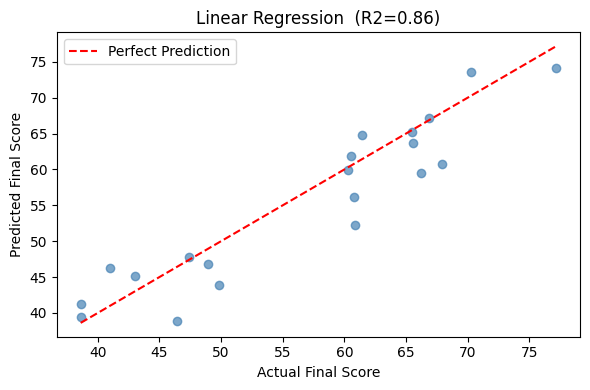

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt

np.random.seed(0)
n=100
study_hrs=np.random.uniform(1,10,n)
prev_score=np.random.uniform(40,95,n)
noise=np.random.normal(0,5,n)
final_score=5*study_hrs+0.4*prev_score+noise
final_score=np.clip(final_score,0,100)

df=pd.DataFrame({
    'study_hrs':study_hrs,
    'prev_score':prev_score,
    'final_score':final_score
})

X=df[['study_hrs','prev_score']]
y=df['final_score']

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Train:{len(X_train)}rows|Test:{len(X_test)}rows")

model=LinearRegression()
model.fit(X_train,y_train)
print(f'Intercept:{model.intercept_:.2f}')
print(f'Coefficient:study_hrs={model.coef_[0]:.2f},prev_score={model.coef_[1]:.2f}')

y_pred=model.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(f'MAE:{mae:.2f} (avg error in mrs)')
print(f'{rmse:.2f} (penalises large errors more)')
print(f'R2:{r2:.3f} (1=perfect, 0=no better than mean)')

plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred,color='steelblue',alpha=0.7)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',label="Perfect Prediction")
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title(f'Linear Regression  (R2={r2:.2f})')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=150)
plt.show()

In [ ]:
#why 2d--x variable


Accuracy:92.1%
Confusion matrix:
[[12  0  0]
 [ 0 13  0]
 [ 0  3 10]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13

    accuracy                           0.92        38
   macro avg       0.94      0.92      0.92        38
weighted avg       0.94      0.92      0.92        38



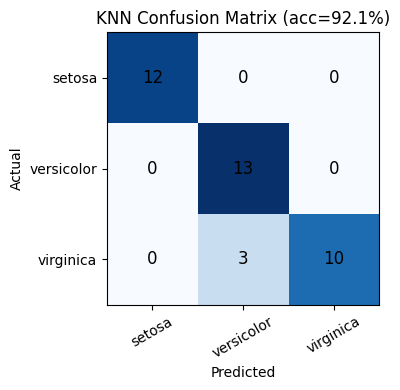

In [6]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
import numpy as np, pandas as pd, matplotlib.pyplot as plt

iris=load_iris()
X,y=iris.data, iris.target
names=iris.target_names

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

y_pred=knn.predict(X_test)

acc=accuracy_score(y_test,y_pred)
print(f'Accuracy:{acc*100:.1f}%')
cm=confusion_matrix(y_test,y_pred)
print('Confusion matrix:')
print(cm)
print(classification_report(y_test,y_pred,target_names=names))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(names, rotation=30); ax.set_yticklabels(names)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'KNN Confusion Matrix (acc={acc*100:.1f}%)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

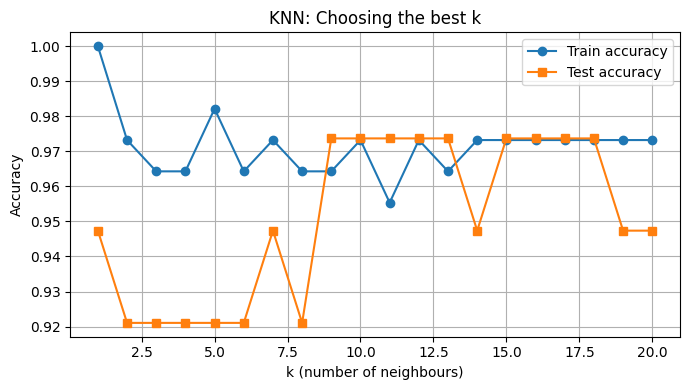

In [7]:
# Try multiple values of k and plot accuracy
k_values  = range(1, 21)
train_acc = []
test_acc  = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train)))
    test_acc.append( accuracy_score(y_test,  knn.predict(X_test)))
plt.figure(figsize=(7, 4))
plt.plot(k_values, train_acc, label='Train accuracy', marker='o')
plt.plot(k_values, test_acc,  label='Test accuracy',  marker='s')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Accuracy')
plt.title('KNN: Choosing the best k')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('knn_k_curve.png', dpi=150)
plt.show()
# Low k = overfit (wiggly boundary); High k = underfit (too smooth)
# Best k is where test accuracy peaks